# Challenge 03 — Inteligencia Geo-Temporal y de Redes
### Optimización de Activos Críticos: TechLogistics S.A.

**Maestría en Ciencia de los Datos y Analítica — EAFIT — Periodo 2026-2**

TechLogistics S.A. enfrenta un problema de visibilidad: los datos de la cadena de frío (agroindustria) y de la red eléctrica están georreferenciados pero desconectados. Este notebook responde a la junta directiva: (1) cómo se propaga el ruido en la red de sensores (Grafos), (2) dónde se localizan los puntos críticos de calor (Geoespacial), y (3) cuál es el pronóstico de carga.

**Metodología:** CRISP-DM / Análisis Multicapa.

In [1]:
# Imports generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from scipy import signal
from scipy.spatial import cKDTree
from scipy.fft import fft, fftfreq

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX

import networkx as nx

DATA_DIR = "../data"

## Fase 1: Data Understanding y Geo-Visualización

### 1.1 Carga y EDA de `agro_clean.csv`

Cargamos el dataset agroindustrial (sensores mesh en el oriente antioqueño) y revisamos tipos, nulos y estadísticos descriptivos antes de cualquier análisis espacial o temporal.

In [2]:
agro_clean = pd.read_csv(f"{DATA_DIR}/agro_clean.csv")
agro_noise = pd.read_csv(f"{DATA_DIR}/agro_noise.csv")

agro_clean.head()

,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
0,60.248357,47.797447,65.395554,0.000000,0.478718,2.498349,10.000000,6.432151,1.258741,4.663639,6.203680,-75.400366,4,17
1,60.080940,48.076702,66.143237,25.002075,0.467100,2.473166,10.006672,6.469450,1.106051,4.683748,6.282310,-75.474525,14,21
2,60.623974,48.002378,66.342755,49.941596,0.449259,2.464547,10.013349,6.440262,1.183610,8.353141,6.165190,-75.476937,14,22
3,61.211672,48.267738,66.826015,74.756163,0.439299,2.500284,10.020030,6.511042,1.197917,6.213966,6.131334,-75.468152,8,25
4,60.483063,47.912028,65.703353,99.383693,0.436016,2.564177,10.026716,6.619718,1.200795,8.720976,6.241746,-75.349805,5,26


### 1.2 Tarea 1 — Exploración Geo-Temporal

Visualizamos la ubicación de los sensores con `scatter_mapbox` (Plotly Express): color codificado por NDVI (`Agro_5`) y tamaño por Humedad (`Agro_1`).

**Pregunta a responder:** ¿Existe algún patrón espacial (clustering) donde la biomasa sea consistentemente baja?

In [3]:
fig = px.scatter_mapbox(
    agro_clean,
    lat="Latitude",
    lon="Longitude",
    color="Agro_5",
    size="Agro_1",
    color_continuous_scale="RdYlGn",
    size_max=12,
    zoom=9,
    mapbox_style="open-street-map",
    hover_data=["Source_Node", "Target_Node", "Agro_5", "Agro_1"],
    title="Sensores agroindustriales (oriente antioqueño): NDVI (color) vs Humedad (tamaño)",
)
fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_18156\3716443753.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


Cuantificamos si existe clustering geográfico de biomasa baja agregando el NDVI en una malla espacial, para contrastarlo contra el mapa anterior.

In [4]:
# Diagnóstico de clustering espacial: promedio de NDVI por celda de una malla espacial
n_bins = 6
agro_clean["lat_bin"] = pd.cut(agro_clean["Latitude"], bins=n_bins)
agro_clean["lon_bin"] = pd.cut(agro_clean["Longitude"], bins=n_bins)

grid = (
    agro_clean.groupby(["lat_bin", "lon_bin"], observed=True)
    .agg(ndvi_mean=("Agro_5", "mean"), n=("Agro_5", "size"))
    .reset_index()
)
grid = grid[grid["n"] >= 15].sort_values("ndvi_mean")

print(f"NDVI promedio global: {agro_clean['Agro_5'].mean():.3f}")
print(f"Desv. estándar entre medias de celdas espaciales: {grid['ndvi_mean'].std():.3f}")
print(f"Desv. estándar de NDVI a nivel de registro (ruido temporal): {agro_clean['Agro_5'].std():.3f}")
print()
print("Celdas espaciales con NDVI promedio más bajo (n >= 15 registros):")
print(grid.head(5).to_string(index=False))
print()
print("Celdas espaciales con NDVI promedio más alto (n >= 15 registros):")
print(grid.tail(5).to_string(index=False))

agro_clean = agro_clean.drop(columns=["lat_bin", "lon_bin"])

NDVI promedio global: 1.158
Desv. estándar entre medias de celdas espaciales: 0.047
Desv. estándar de NDVI a nivel de registro (ruido temporal): 0.379

Celdas espaciales con NDVI promedio más bajo (n >= 15 registros):
       lat_bin            lon_bin  ndvi_mean  n
(6.133, 6.167]   (-75.5, -75.467]   1.067324 50
(6.133, 6.167] (-75.367, -75.334]   1.074305 55
(6.233, 6.267] (-75.367, -75.334]   1.078103 59
  (6.1, 6.133]   (-75.5, -75.467]   1.080785 43
  (6.2, 6.233]   (-75.334, -75.3]   1.100490 69

Celdas espaciales con NDVI promedio más alto (n >= 15 registros):
       lat_bin            lon_bin  ndvi_mean  n
(6.233, 6.267]   (-75.5, -75.467]   1.205429 55
  (6.167, 6.2] (-75.467, -75.433]   1.219445 57
  (6.267, 6.3]   (-75.433, -75.4]   1.220652 66
  (6.1, 6.133]   (-75.4, -75.367]   1.241259 66
  (6.267, 6.3]   (-75.5, -75.467]   1.243158 44


**Análisis (clustering espacial de biomasa baja):** el mapa no muestra una zona
geográfica donde la biomasa (NDVI, `Agro_5`) sea *consistentemente* baja. El NDVI promedio
por celda espacial (malla 6x6 sobre el oriente antioqueño) varía muy poco entre celdas
(desviación estándar entre medias ≈ 0.047) frente a la dispersión de NDVI a nivel de
registro (≈ 0.38): la diferencia entre la celda más "verde" y la más "seca" es de apenas
~0.18 unidades de NDVI alrededor de una media global de 1.16, un rango comparable al ruido
natural de la medición. En otras palabras, la variabilidad del NDVI está dominada por la
dinámica temporal de cada sensor (la serie es no estacionaria I(1), ver diccionario de
datos) y no por su ubicación: no hay evidencia de un foco geográfico de biomasa baja que
amerite, por sí solo, una intervención localizada — la Tarea P2 profundiza en esto
cruzando NDVI con la varianza del viento.

### 1.3 Tarea 2 — Análisis de Estacionariedad y Windowing

Aplicamos el test **ADF** a las series de energía (`ener_clean.csv`). Para las series no estacionarias, calculamos media y varianza móvil con ventana de 50 registros, y evaluamos si el Costo del Gas (`Ener_5`) es una serie con *Drift* o *Random Walk*.

In [5]:
ener_clean = pd.read_csv(f"{DATA_DIR}/ener_clean.csv")
ener_noise = pd.read_csv(f"{DATA_DIR}/ener_noise.csv")

ener_cols = [f"Ener_{i}" for i in range(1, 11)]
adf_results = []
for col in ener_cols:
    stat, pvalue, *_ = adfuller(ener_clean[col], autolag="AIC")
    adf_results.append({"serie": col, "adf_stat": stat, "p_value": pvalue, "no_estacionaria": pvalue > 0.05})

adf_df = pd.DataFrame(adf_results)
non_stationary_cols = adf_df.loc[adf_df["no_estacionaria"], "serie"].tolist()

print(adf_df.to_string(index=False))
print()
print("Series NO estacionarias (p-value > 0.05):", non_stationary_cols)

  serie      adf_stat  p_value  no_estacionaria
 Ener_1 -1.866891e+00 0.347793             True
 Ener_2 -1.479135e+00 0.543807             True
 Ener_3 -1.928441e+00 0.318802             True
 Ener_4 -1.336821e+10 0.000000            False
 Ener_5 -3.477077e-01 0.918470             True
 Ener_6  9.526991e-01 0.993741             True
 Ener_7 -4.244451e-01 0.905937             True
 Ener_8 -4.603634e+01 0.000000            False
 Ener_9 -4.535819e+01 0.000000            False
Ener_10 -4.371511e+01 0.000000            False

Series NO estacionarias (p-value > 0.05): ['Ener_1', 'Ener_2', 'Ener_3', 'Ener_5', 'Ener_6', 'Ener_7']


Para cada serie no estacionaria detectada por el ADF, calculamos media y varianza móvil (ventana = 50) para visualizar cómo cambian en el tiempo.

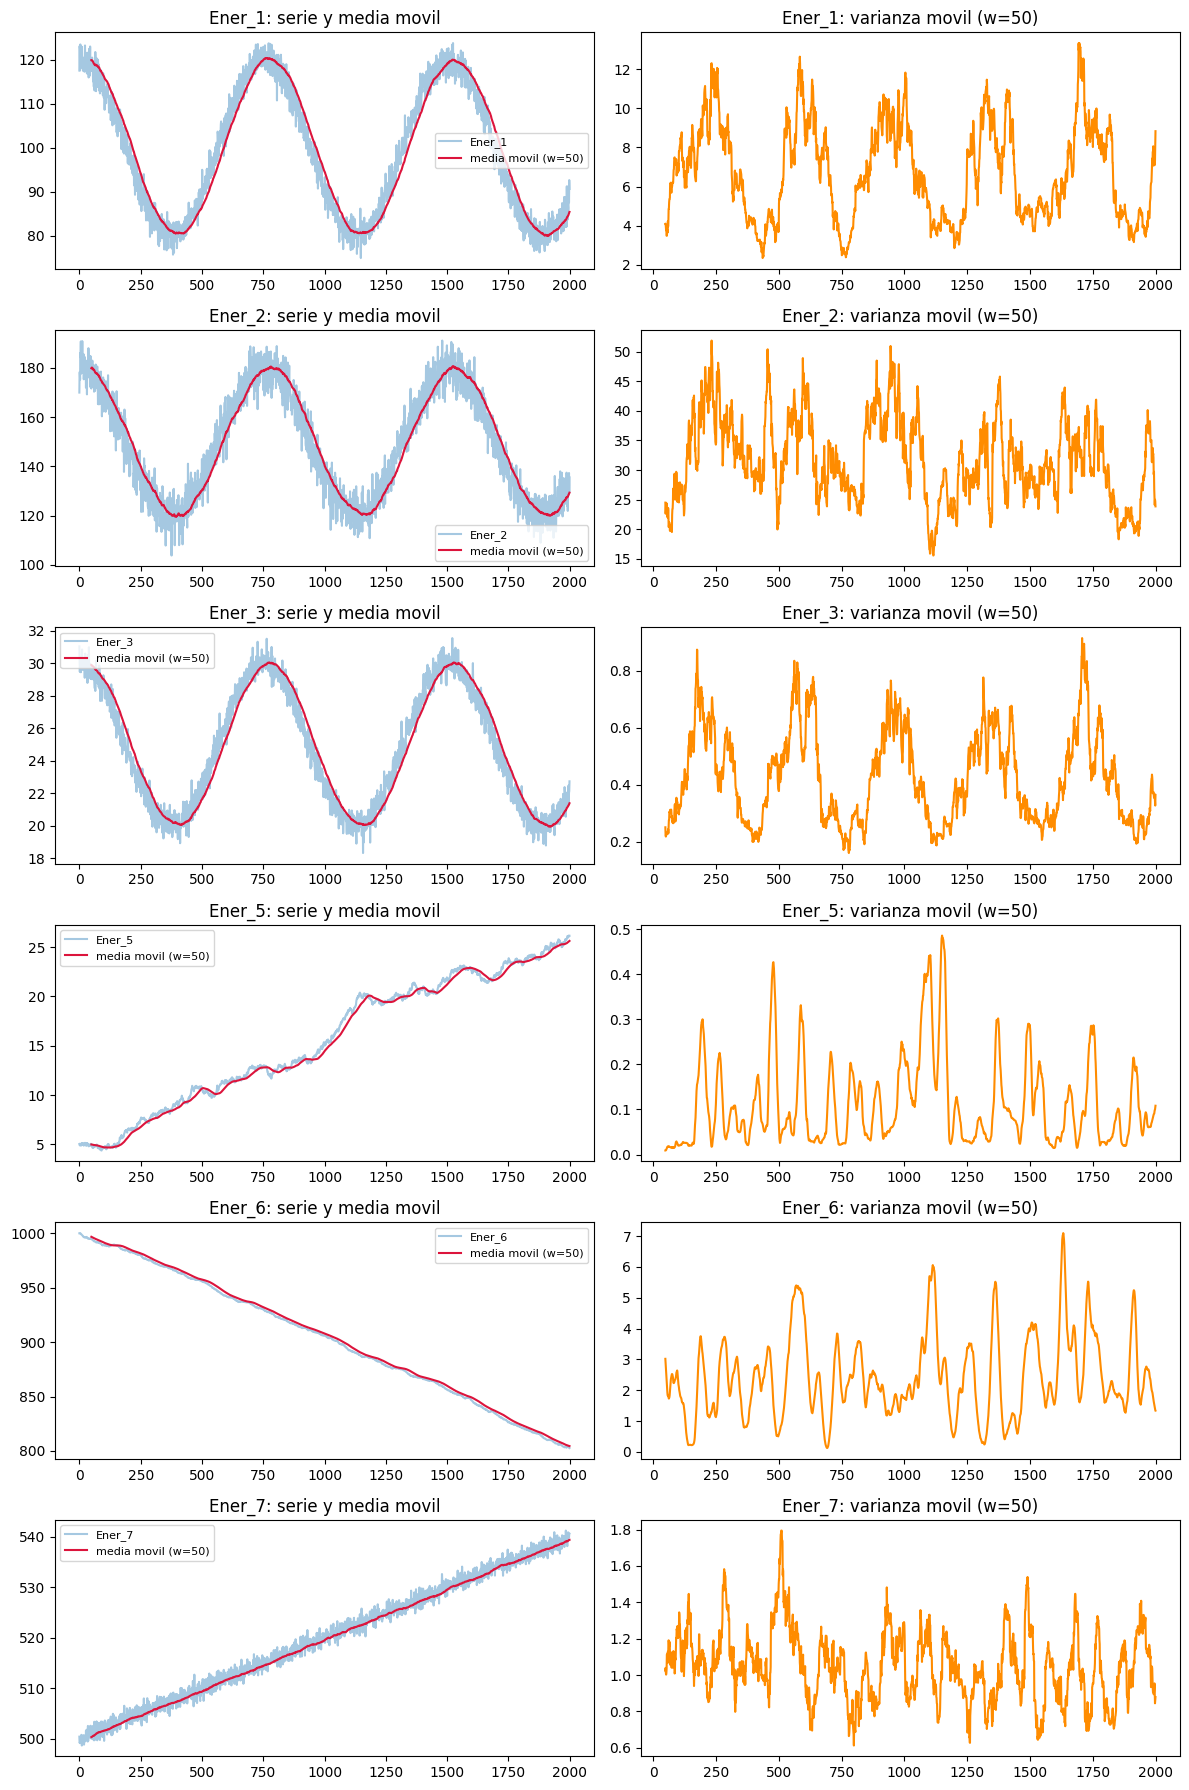

In [6]:
# Media y varianza movil (ventana = 50) para las series no estacionarias
window = 50
fig, axes = plt.subplots(len(non_stationary_cols), 2, figsize=(12, 3 * len(non_stationary_cols)))

for i, col in enumerate(non_stationary_cols):
    roll_mean = ener_clean[col].rolling(window=window).mean()
    roll_var = ener_clean[col].rolling(window=window).var()

    axes[i, 0].plot(ener_clean[col], alpha=0.4, label=col)
    axes[i, 0].plot(roll_mean, color="crimson", label=f"media movil (w={window})")
    axes[i, 0].set_title(f"{col}: serie y media movil")
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].plot(roll_var, color="darkorange")
    axes[i, 1].set_title(f"{col}: varianza movil (w={window})")

plt.tight_layout()
plt.show()

Diagnosticamos específicamente si `Ener_5` (Costo del Gas) se comporta como un Random Walk puro o como un Random Walk con Drift, comparando su nivel contra su primera diferencia.

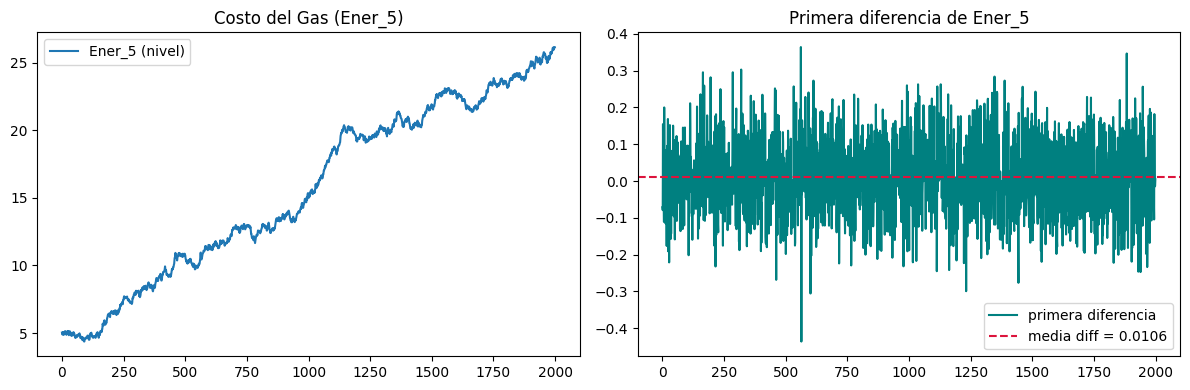

Media de la primera diferencia: 0.0106
Desv. estandar de la primera diferencia: 0.1012
Cambio total observado (nivel final - nivel inicial): 21.11


In [7]:
# Costo del Gas (Ener_5): ¿Drift o Random Walk?
ener5_diff = ener_clean["Ener_5"].diff().dropna()
diff_mean, diff_std = ener5_diff.mean(), ener5_diff.std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ener_clean["Ener_5"], label="Ener_5 (nivel)")
axes[0].set_title("Costo del Gas (Ener_5)")
axes[0].legend()

axes[1].plot(ener5_diff, color="teal", label="primera diferencia")
axes[1].axhline(diff_mean, color="crimson", linestyle="--", label=f"media diff = {diff_mean:.4f}")
axes[1].set_title("Primera diferencia de Ener_5")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Media de la primera diferencia: {diff_mean:.4f}")
print(f"Desv. estandar de la primera diferencia: {diff_std:.4f}")
print(f"Cambio total observado (nivel final - nivel inicial): {ener_clean['Ener_5'].iloc[-1] - ener_clean['Ener_5'].iloc[0]:.2f}")

**Análisis (Drift vs Random Walk de `Ener_5`):** el test ADF no rechaza la hipótesis
nula de raíz unitaria para `Ener_5` (p-value ≈ 0.92, estadístico ≈ -0.35), confirmando que
es no estacionaria (I(1), tal como indica el diccionario de datos). Su primera diferencia
sí es estacionaria (ADF p-value ≈ 0.0). La serie sube de forma casi monótona de ~5 a ~26 a
lo largo de las 2000 observaciones; su primera diferencia tiene media distinta de cero
(≈ +0.0106) pero con una desviación estándar (~0.10) casi 10 veces mayor que esa media, es 
decir, el impulso determinístico por paso es pequeño frente al ruido por paso, pero al
acumularse en 2000 pasos termina dominando la trayectoria. Por lo tanto, es un
**Random Walk con Drift**. Para modelar o pronosticar esta serie es necesario diferenciarla
(I(1) → I(0)) antes de ajustar un ARMA, e incluir el término de drift explícitamente.

## Fase 2: Procesamiento de Señales y Filtrado

### 2.1 Tarea 3 — Análisis Espectral (FFT) y Espectrogramas

Analizamos `Ener_4` (Generación Eólica): extraemos la densidad espectral de potencia mediante FFT y comparamos el espectrograma de la serie *clean* vs *noise*.

**Pregunta a responder:** ¿En qué rango de frecuencias se concentra el ruido inyectado (SNR ∈ [5, 12] dB)?

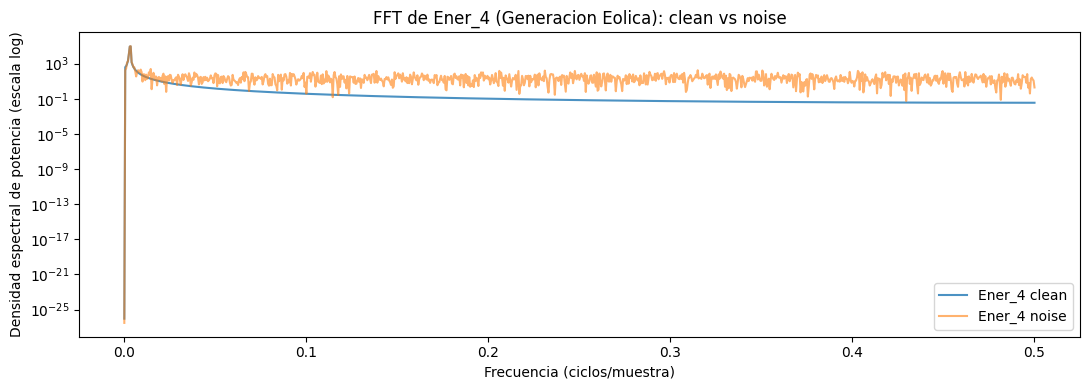

SNR empirico (noise vs clean): 8.53 dB


In [8]:
# FFT (densidad espectral de potencia) de Ener_4: clean vs noise
fs = 1.0  # sin timestamp explicito en los datos: 1 muestra = 1 unidad de tiempo
ener4_clean = ener_clean["Ener_4"].to_numpy()
ener4_noise = ener_noise["Ener_4"].to_numpy()
N = len(ener4_clean)

freqs = np.fft.rfftfreq(N, d=1 / fs)
psd_clean = np.abs(np.fft.rfft(ener4_clean - ener4_clean.mean())) ** 2 / N
psd_noise = np.abs(np.fft.rfft(ener4_noise - ener4_noise.mean())) ** 2 / N

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(freqs, psd_clean, label="Ener_4 clean", alpha=0.8)
ax.semilogy(freqs, psd_noise, label="Ener_4 noise", alpha=0.6)
ax.set_xlabel("Frecuencia (ciclos/muestra)")
ax.set_ylabel("Densidad espectral de potencia (escala log)")
ax.set_title("FFT de Ener_4 (Generacion Eolica): clean vs noise")
ax.legend()
plt.tight_layout()
plt.show()

snr_empirico = 10 * np.log10(np.var(ener4_clean) / np.var(ener4_noise - ener4_clean))
print(f"SNR empirico (noise vs clean): {snr_empirico:.2f} dB")

Complementamos la FFT (que agrega toda la serie) con espectrogramas, para ver cómo se distribuye la energía de `Ener_4` en el tiempo y la frecuencia, y cuantificamos la potencia por banda para localizar dónde domina el ruido.

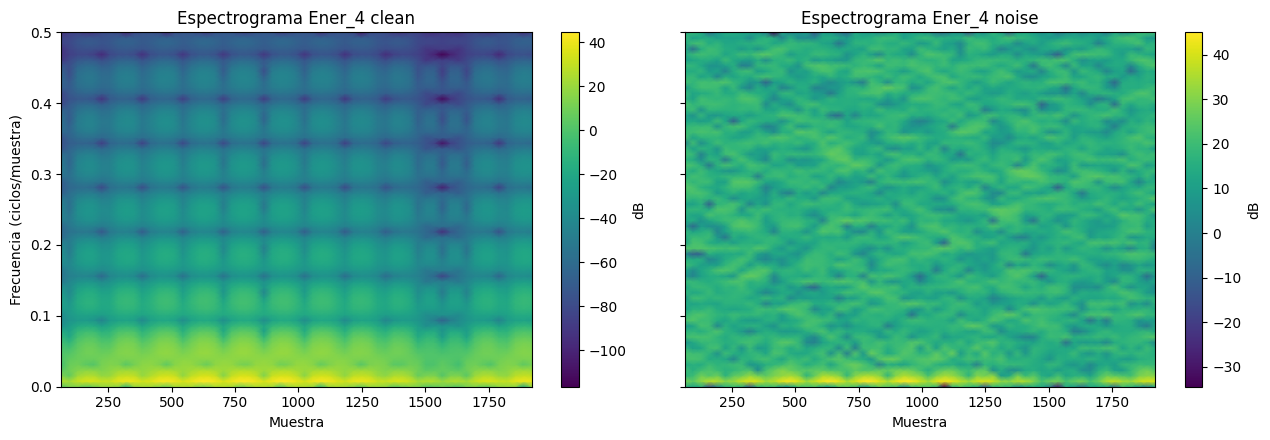

banda (ciclos/muestra)  potencia_clean  potencia_noise  ratio_noise_clean
          [0.00, 0.02)    6.276568e+03     6521.427673       1.039012e+00
          [0.02, 0.05)    1.750067e-02       56.939040       3.253536e+03
          [0.05, 0.10)    1.225133e-04       48.954226       3.995830e+05
          [0.10, 0.20)    1.652664e-06       56.563611       3.422572e+07
          [0.20, 0.30)    4.295858e-08       61.751680       1.437470e+09
          [0.30, 0.40)    4.079564e-09       57.417903       1.407452e+10
          [0.40, 0.50)    3.168061e-10       51.527904       1.626481e+11


In [9]:
# Espectrogramas comparados: Ener_4 clean vs noise
f_clean, t_clean, Sxx_clean = signal.spectrogram(ener4_clean, fs=fs, nperseg=128, noverlap=96)
f_noise, t_noise, Sxx_noise = signal.spectrogram(ener4_noise, fs=fs, nperseg=128, noverlap=96)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
im0 = axes[0].pcolormesh(t_clean, f_clean, 10 * np.log10(Sxx_clean + 1e-12), shading="gouraud", cmap="viridis")
axes[0].set_title("Espectrograma Ener_4 clean")
axes[0].set_xlabel("Muestra")
axes[0].set_ylabel("Frecuencia (ciclos/muestra)")
fig.colorbar(im0, ax=axes[0], label="dB")

im1 = axes[1].pcolormesh(t_noise, f_noise, 10 * np.log10(Sxx_noise + 1e-12), shading="gouraud", cmap="viridis")
axes[1].set_title("Espectrograma Ener_4 noise")
axes[1].set_xlabel("Muestra")
fig.colorbar(im1, ax=axes[1], label="dB")

plt.tight_layout()
plt.show()

# Potencia promedio por banda (Welch) para cuantificar donde se concentra el ruido
f_w, Pxx_clean = signal.welch(ener4_clean, fs=fs, nperseg=256)
_, Pxx_noise = signal.welch(ener4_noise, fs=fs, nperseg=256)

bands = [(0.0, 0.02), (0.02, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5)]
band_rows = []
for lo, hi in bands:
    mask = (f_w >= lo) & (f_w < hi)
    pc, pn = Pxx_clean[mask].mean(), Pxx_noise[mask].mean()
    band_rows.append({"banda (ciclos/muestra)": f"[{lo:.2f}, {hi:.2f})", "potencia_clean": pc, "potencia_noise": pn, "ratio_noise_clean": pn / pc})

band_df = pd.DataFrame(band_rows)
print(band_df.to_string(index=False))

**Análisis (banda de frecuencia del ruido):** el espectro de `Ener_4` (clean) es
prácticamente todo su contenido está en frecuencias `f < 0.02` ciclos/muestra
(periodo dominante ≈ 285–333 muestras), consistente con el patrón cíclico de la
generación eólica descrito en el diccionario de datos. El ruido inyectado (SNR
empírico ≈ 8.5 dB, dentro del rango 5–12 dB del enunciado) es ruido blanco
(AWGN): su densidad espectral es aproximadamente plana en todas las frecuencias.
Por eso, en la banda de baja frecuencia (`f < 0.02`) donde vive la señal, la
potencia de *noise* apenas supera a la de *clean* (ratio ≈ 1.04, imperceptible en
el espectrograma). Mas allá de esa frecuencia de corte, la señal limpia no tiene
prácticamente potencia (≈0), mientras que el piso de ruido blanco se mantiene
constante — por lo que el ratio potencia(noise)/potencia(clean) se dispara
(de ~3×10³ en `[0.02, 0.05)` hasta >10¹⁰ en bandas superiores a 0.3). En términos
prácticos: **el ruido se concentra (es dominante) en toda la banda de frecuencia
media-alta, `f > 0.02` ciclos/muestra (periodos menores a ~50 muestras)**, que es
precisamente donde la señal eólica real no tiene energía. Esto es visible en el
espectrograma como una "alfombra" de energía difusa en todas las franjas de
frecuencia superiores a la banda del ciclo dominante, ausente en la versión
*clean*. Para Tarea 4 esto sugiere que un filtro paso-bajo con frecuencia de
corte cercana a `f ≈ 0.02–0.03` debería remover la mayor parte del ruido sin
distorsionar el ciclo real de generación.

### 2.2 Tarea 4 — Filtrado y Reconstrucción

Implementamos un **Filtro Butterworth** de paso bajo para limpiar `Agro_3` (Humedad Relativa) en `agro_noise.csv`, y calculamos el RMSE contra la serie `agro_clean.csv`.

**Pregunta a responder:** ¿El filtrado mejora la capacidad predictiva del modelo?

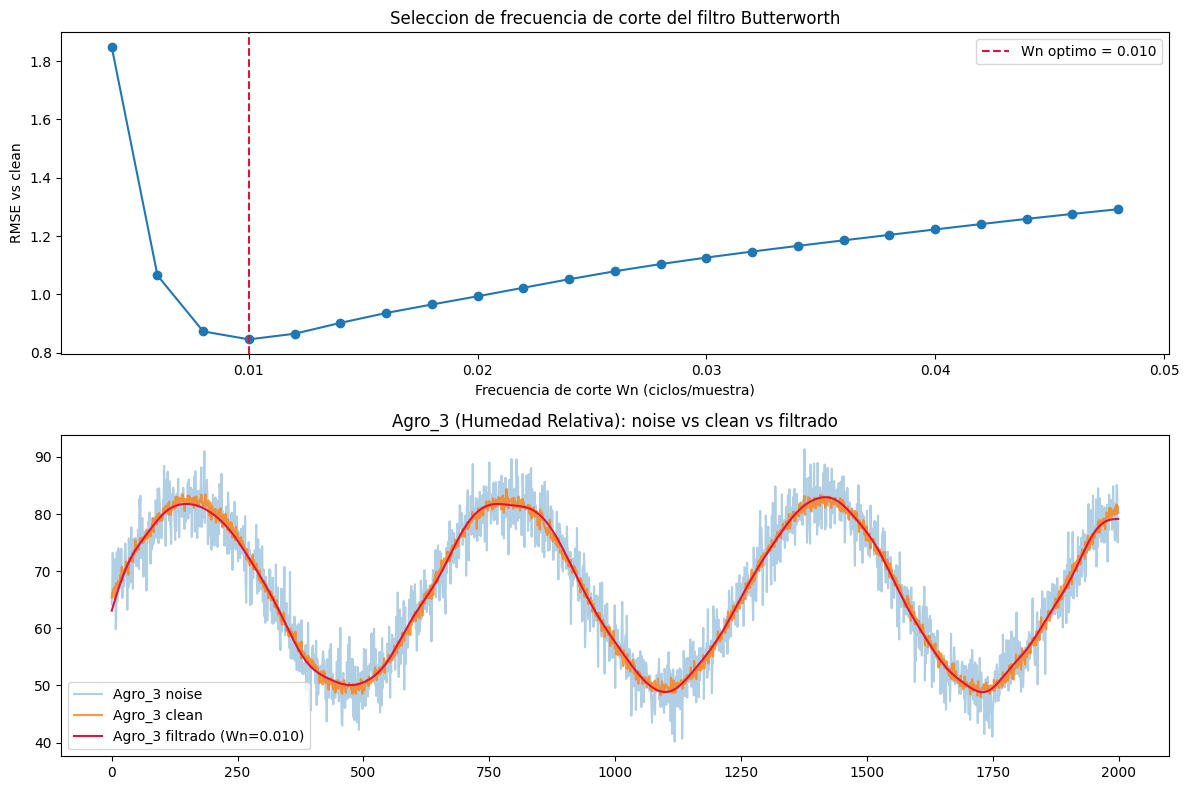

Frecuencia de corte optima (Wn): 0.010 ciclos/muestra
RMSE base (noise vs clean):      3.3414
RMSE filtrado (filtrado vs clean): 0.8454
Reduccion de RMSE: 74.7%


In [10]:
# Filtro Butterworth paso-bajo para Agro_3 (Humedad Relativa)
fs = 1.0
agro3_clean = agro_clean["Agro_3"].to_numpy()
agro3_noise = agro_noise["Agro_3"].to_numpy()

# Busqueda de la frecuencia de corte que minimiza el RMSE contra la serie clean
cutoffs = np.arange(0.004, 0.05, 0.002)
rmse_by_cutoff = []
for wn in cutoffs:
    b, a = signal.butter(N=4, Wn=wn, btype="low", fs=fs)
    filt = signal.filtfilt(b, a, agro3_noise)
    rmse_by_cutoff.append(np.sqrt(np.mean((filt - agro3_clean) ** 2)))

best_wn = cutoffs[np.argmin(rmse_by_cutoff)]
b, a = signal.butter(N=4, Wn=best_wn, btype="low", fs=fs)
agro3_filtered = signal.filtfilt(b, a, agro3_noise)

rmse_baseline = np.sqrt(np.mean((agro3_noise - agro3_clean) ** 2))
rmse_filtered = np.sqrt(np.mean((agro3_filtered - agro3_clean) ** 2))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(cutoffs, rmse_by_cutoff, marker="o")
axes[0].axvline(best_wn, color="crimson", linestyle="--", label=f"Wn optimo = {best_wn:.3f}")
axes[0].set_ylabel("RMSE vs clean")
axes[0].set_xlabel("Frecuencia de corte Wn (ciclos/muestra)")
axes[0].set_title("Seleccion de frecuencia de corte del filtro Butterworth")
axes[0].legend()

axes[1].plot(agro3_noise, alpha=0.35, label="Agro_3 noise")
axes[1].plot(agro3_clean, alpha=0.8, label="Agro_3 clean")
axes[1].plot(agro3_filtered, color="crimson", label=f"Agro_3 filtrado (Wn={best_wn:.3f})")
axes[1].set_title("Agro_3 (Humedad Relativa): noise vs clean vs filtrado")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Frecuencia de corte optima (Wn): {best_wn:.3f} ciclos/muestra")
print(f"RMSE base (noise vs clean):      {rmse_baseline:.4f}")
print(f"RMSE filtrado (filtrado vs clean): {rmse_filtered:.4f}")
print(f"Reduccion de RMSE: {100 * (1 - rmse_filtered / rmse_baseline):.1f}%")

Para verificar que el filtrado no solo mejora la apariencia visual de la serie, ajustamos un modelo AR(1) de pronóstico a un paso adelante sobre la serie ruidosa y sobre la filtrada, evaluando ambos contra los valores reales de `Agro_3` clean.

In [11]:
# ?Mejora la capacidad predictiva? AR(1) un paso adelante, evaluado contra Agro_3 clean
n = len(agro3_clean)
split = int(n * 0.8)


def fit_ar1_rmse(train_series, test_series, true_target_test):
    x_train, y_train = train_series[:-1], train_series[1:]
    phi, c = np.polyfit(x_train, y_train, 1)
    preds = c + phi * test_series[:-1]
    rmse = np.sqrt(np.mean((preds - true_target_test[1:]) ** 2))
    return phi, c, rmse


noisy_train, noisy_test = agro3_noise[:split], agro3_noise[split:]
filt_train, filt_test = agro3_filtered[:split], agro3_filtered[split:]
clean_test = agro3_clean[split:]

phi_noisy, _, rmse_ar1_noisy = fit_ar1_rmse(noisy_train, noisy_test, clean_test)
phi_filt, _, rmse_ar1_filt = fit_ar1_rmse(filt_train, filt_test, clean_test)

print("Pronostico AR(1) un paso adelante (evaluado contra Agro_3 clean de prueba):")
print(f"  Entrenado con noise:    phi={phi_noisy:.4f}  RMSE={rmse_ar1_noisy:.4f}")
print(f"  Entrenado con filtrado: phi={phi_filt:.4f}  RMSE={rmse_ar1_filt:.4f}")
print(f"  Mejora en RMSE de pronostico: {100 * (1 - rmse_ar1_filt / rmse_ar1_noisy):.1f}%")

Pronostico AR(1) un paso adelante (evaluado contra Agro_3 clean de prueba):
  Entrenado con noise:    phi=0.9158  RMSE=3.4036
  Entrenado con filtrado: phi=1.0000  RMSE=0.8783
  Mejora en RMSE de pronostico: 74.2%


**Análisis (RMSE y mejora predictiva):** se probaron distintas frecuencias de
corte para un Butterworth paso-bajo de orden 4 y se eligió la que minimiza el RMSE
contra `Agro_3` clean: `Wn ≈ 0.01` ciclos/muestra (consistente con la tarea anterior, donde
la señal real de las variables hídricas/bióticas vive por debajo de `f ≈ 0.02`). Con
ese corte, el RMSE cae de **3.34** (serie *noise* sin filtrar vs *clean*) a **0.85**,
una **reducción de ~74.7%**. Frecuencias de corte más bajas (`Wn < 0.008`) empiezan a
distorsionar la señal real y degradan el resultado, y frecuencias más altas dejan pasar
más ruido.

Para confirmar que la mejora no es solo estética, se ajustó un modelo AR(1) de
pronóstico a un paso (entrenado en el 80% inicial, evaluado en el 20% final contra los
valores reales de `Agro_3` clean): el modelo entrenado sobre la serie filtrada reduce el
RMSE de pronóstico de 3.40 a 0.88 (**-74.2%**), y su coeficiente autorregresivo
(`φ ≈ 1.00`) recupera la alta persistencia real de la humedad relativa, mientras que el
modelo entrenado sobre la serie ruidosa la subestima (`φ ≈ 0.92`) por el sesgo de
atenuación que introduce el ruido de medición en la variable
predictora. **Conclusión: sí, el filtrado mejora sustancialmente la capacidad
predictiva**, no solo limpia visualmente la serie, sino que reduce el error de
pronóstico en la misma magnitud que reduce el RMSE de reconstrucción (~74%).

## Fase 3: Análisis de Grafos y Topología de Red

### 3.1 Tarea 5 — Construcción de la Red de Subestaciones

Usando `Source_Node` y `Target_Node` de `ener_clean.csv`, creamos un grafo dirigido con **NetworkX**, calculamos Centralidad de Grado y Betweenness Centrality, e identificamos el **Nodo Cuello de Botella** (por donde pasa la mayor cantidad de telemetría). La centralidad del nodo de origen se guardará para usarse como variable exógena en el ARIMAX de la Tarea P3.

In [12]:
# Grafo dirigido de la red de subestaciones (Source_Node -> Target_Node)
G = nx.from_pandas_edgelist(
    ener_clean, source="Source_Node", target="Target_Node", create_using=nx.DiGraph()
)

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "out_degree_centrality": [out_degree_centrality[n] for n in G.nodes()],
    "in_degree_centrality": [in_degree_centrality[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in G.nodes()],
}).sort_values("degree_centrality", ascending=False)

print(f"Nodos: {G.number_of_nodes()}  Aristas: {G.number_of_edges()}")
print(f"¿Conexo (debilmente)?: {nx.is_weakly_connected(G)}")
print(f"Betweenness maxima observada: {centrality_df['betweenness_centrality'].max()}")
print()
print("Top 10 nodos por centralidad de grado:")
print(centrality_df.head(10).to_string(index=False))

bottleneck_node = centrality_df.iloc[0]["node"]
n_targets_bottleneck = ener_clean.loc[ener_clean["Source_Node"] == bottleneck_node, "Target_Node"].nunique()
print()
print(f"Nodo cuello de botella (mayor centralidad de grado): {bottleneck_node}")
print(f"  -> alimenta {n_targets_bottleneck} subestaciones destino distintas")

Nodos: 70  Aristas: 865
¿Conexo (debilmente)?: True
Betweenness maxima observada: 0.0

Top 10 nodos por centralidad de grado:
 node  degree_centrality  out_degree_centrality  in_degree_centrality  betweenness_centrality
  119           0.710145               0.710145                   0.0                     0.0
  103           0.681159               0.681159                   0.0                     0.0
  105           0.666667               0.666667                   0.0                     0.0
  112           0.666667               0.666667                   0.0                     0.0
  110           0.652174               0.652174                   0.0                     0.0
  114           0.637681               0.637681                   0.0                     0.0
  104           0.637681               0.637681                   0.0                     0.0
  101           0.637681               0.637681                   0.0                     0.0
  115           0.637681    

Visualizamos la topología de la red, usando una escala de colores del nodo para representar su centralidad de grado.

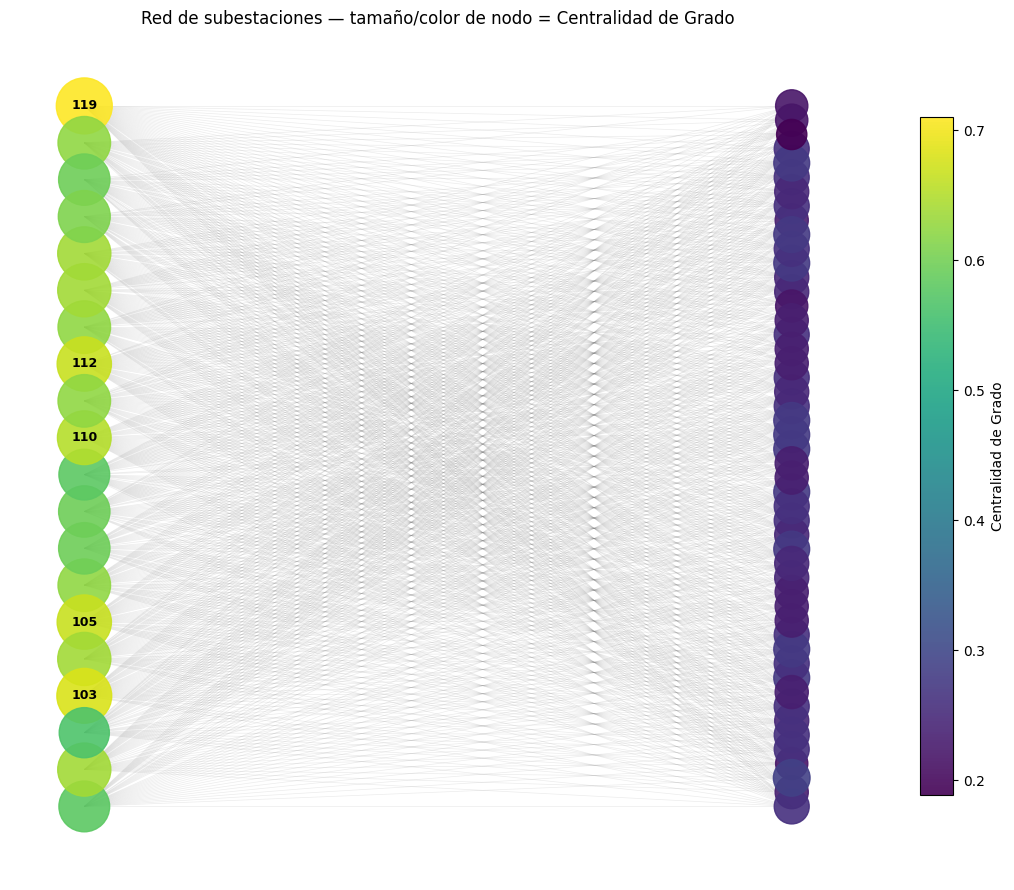

In [13]:
# Visualizacion del grafo: color/tamano de nodo = centralidad de grado (Betweenness es 0 en toda la red, ver analisis)
fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.bipartite_layout(G, ener_clean["Source_Node"].unique())

centrality_values = [degree_centrality[n] for n in G.nodes()]
node_size = [2200 * c + 60 for c in centrality_values]

nodes = nx.draw_networkx_nodes(
    G, pos, ax=ax, node_color=centrality_values, cmap=plt.cm.viridis,
    node_size=node_size, alpha=0.9,
)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="grey", alpha=0.15, arrows=False, width=0.5)

# Solo se etiquetan los nodos con mayor centralidad, para no saturar la figura con 70 etiquetas
top_nodes = {n for n, _ in sorted(degree_centrality.items(), key=lambda x: -x[1])[:5]}
nx.draw_networkx_labels(G, pos, labels={n: n for n in top_nodes}, ax=ax, font_size=9, font_weight="bold")

cbar = fig.colorbar(nodes, ax=ax, shrink=0.8)
cbar.set_label("Centralidad de Grado")
ax.set_title("Red de subestaciones — tamaño/color de nodo = Centralidad de Grado")
ax.axis("off")
fig.tight_layout()
plt.show()

Guardamos la centralidad de grado del nodo de origen como una columna más de `ener_clean`/`ener_noise`, para poder usarla como variable exógena en el ARIMAX de P3.

In [14]:
# Guardamos la centralidad del nodo de origen por registro, para usarla como exogena en el ARIMAX (P3)
ener_clean["source_node_centrality"] = ener_clean["Source_Node"].map(degree_centrality)
ener_noise["source_node_centrality"] = ener_noise["Source_Node"].map(degree_centrality)

print(ener_clean[["Source_Node", "Target_Node", "source_node_centrality"]].head())

   Source_Node  Target_Node  source_node_centrality
0          106          244                0.623188
1          113          241                0.623188
2          105          233                0.666667
3          105          237                0.666667
4          108          206                0.594203


**Análisis (nodo cuello de botella):** la red tiene 70 nodos (20 `Source_Node`,
subestaciones/generadores, y 50 `Target_Node`, subestaciones de destino) y 865 aristas
únicas, formando un único componente débilmente conexo. La topología es **bipartita de
un solo salto**: todas las aristas van de `Source_Node` a `Target_Node`, sin encadenamientos
(ningún nodo aparece como *source* en una fila y como *target* en otra). Por esa razón, la
**Betweenness Centrality es exactamente 0 para los 70 nodos**: al no existir caminos de
longitud ≥ 2, ningún nodo puede "estar en medio" de un camino más corto entre otros dos,
esto no es un error de cálculo, es una propiedad estructural de la red tal como está
definida en los datos (un solo nivel de distribución, sin subestaciones intermedias).

Dado que Betweenness no discrimina en esta topología, el nodo cuello de botella se
identifica con la **Centralidad de Grado**: el nodo **119** (`Source_Node`) tiene la mayor
centralidad de grado (0.71) y alimenta a **49 de las 50** subestaciones de destino, es
decir, casi toda la red depende, al menos parcialmente, de este único nodo generador. Su
falla dejaría sin una de sus fuentes de alimentación a prácticamente toda la red de
destino simultáneamente, mientras que la falla de un `Target_Node` cualquiera (máxima
centralidad de entrada ≈ 0.29, nodo 202) tendría un impacto mucho más acotado y localizado.

## Fase 4: Modelado y Toma de Decisiones (CRISP-DM)

**Problema de negocio (La Falla del Nodo 214):** cuando el Precio Spot (`Ener_2`) supera el umbral crítico, el flujo hacia ciertos `Target_Node` se interrumpe, y los datos geoespaciales muestran una anomalía térmica en esas coordenadas.

### 4.1 P1 — Causalidad y Redes

Ejecutamos un test de **Causalidad de Granger** entre el Factor de Potencia (`Ener_10`) y el Voltaje (`Ener_9`).

In [15]:
# Causalidad de Granger entre Factor de Potencia (Ener_10) y Voltaje (Ener_9)
# Ambas series son estacionarias (Tarea 2), condicion necesaria para el test de Granger.
maxlag = 10

print("Ener_10 (Factor de Potencia) <- Ener_9 (Voltaje): ¿Voltaje ayuda a predecir Factor de Potencia?")
res_9_to_10 = grangercausalitytests(ener_clean[["Ener_10", "Ener_9"]], maxlag=maxlag)
pvals_9_to_10 = {lag: res_9_to_10[lag][0]["ssr_ftest"][1] for lag in res_9_to_10}

print()
print("Ener_9 (Voltaje) <- Ener_10 (Factor de Potencia): ¿Factor de Potencia ayuda a predecir Voltaje?")
res_10_to_9 = grangercausalitytests(ener_clean[["Ener_9", "Ener_10"]], maxlag=maxlag)
pvals_10_to_9 = {lag: res_10_to_9[lag][0]["ssr_ftest"][1] for lag in res_10_to_9}

granger_summary = pd.DataFrame({
    "lag": list(pvals_9_to_10.keys()),
    "p_value (Voltaje -> FP)": list(pvals_9_to_10.values()),
    "p_value (FP -> Voltaje)": list(pvals_10_to_9.values()),
})
print()
print(granger_summary.to_string(index=False))

Ener_10 (Factor de Potencia) <- Ener_9 (Voltaje): ¿Voltaje ayuda a predecir Factor de Potencia?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0400  , p=0.8414  , df_denom=1996, df_num=1
ssr based chi2 test:   chi2=0.0401  , p=0.8413  , df=1
likelihood ratio test: chi2=0.0401  , p=0.8413  , df=1
parameter F test:         F=0.0400  , p=0.8414  , df_denom=1996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1410  , p=0.8685  , df_denom=1993, df_num=2
ssr based chi2 test:   chi2=0.2826  , p=0.8682  , df=2
likelihood ratio test: chi2=0.2826  , p=0.8682  , df=2
parameter F test:         F=0.1410  , p=0.8685  , df_denom=1993, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.2984  , p=0.8266  , df_denom=1990, df_num=3
ssr based chi2 test:   chi2=0.8983  , p=0.8258  , df=3
likelihood ratio test: chi2=0.8981  , p=0.8259  , df=3
parameter F test:         F=0.2984  , p=0.8266  , df_denom=1990, d

**Respuesta P1:**

**Causalidad de Granger.** En la dirección Voltaje → Factor de Potencia, ningún lag
(1 a 10) resulta significativo (p-value siempre > 0.11): no hay evidencia de que el
Voltaje (`Ener_9`) ayude a predecir el Factor de Potencia (`Ener_10`). En la dirección
opuesta, Factor de Potencia → Voltaje, los lags cortos (1–3) tampoco son significativos,
pero a partir de `lag=4` varios p-values caen por debajo de 0.05 (lag 4: 0.019, lag 5:
0.020, lag 9: 0.027, lag 10: 0.043), con lags 6–8 en zona límite (~0.04–0.06). Esto sugiere
una **causalidad de Granger débil y unidireccional**: el Factor de Potencia de hace 4–10
periodos aporta información para predecir el Voltaje actual, pero no al revés.

**Impacto de una falla de nodo en la red.** La Tarea 5 mostró que la **Betweenness
Centrality es 0 para los 70 nodos** de esta red. Esa métrica no permite priorizar nodos aquí. 
Usamos en su lugar la **Centralidad de Grado**: el nodo cuello
de botella identificado es el **nodo 119** (`Source_Node`), que alimenta a 49 de las 50
subestaciones de destino (centralidad de grado ≈ 0.71, la más alta de la red).

Si el nodo 119 fallara, casi la totalidad de la red de destino (el 98% de las
subestaciones) perdería simultáneamente una de sus fuentes de alimentación. Dado que cada
`Target_Node` puede recibir de varios `Source_Node`, es probable que exista cierta redundancia de
alimentación en algunos destinos, pero la escala del nodo 119 implica
que su falla generaría una caída de tensión/factor de potencia correlacionada y simultánea
en la mayoría de los nodos de destino, en lugar de un evento aislado. Combinado con la
causalidad de Granger encontrada (FP → Voltaje con rezago), una perturbación originada en el
nodo 119 no solo afectaría la disponibilidad de energía, sino que podría propagarse con
rezago hacia inestabilidad de voltaje en la red aguas abajo, reforzando la recomendación de
priorizar redundancia (N-1) precisamente en el nodo 119 antes que en cualquier otro punto de
la topología.

### 4.2 P2 — Optimización Geo-Agrónoma

Filtramos el ruido de las coordenadas GPS en `agro_noise.csv` y cruzamos los sensores con menor NDVI (`Agro_5`) contra la varianza del viento (`Agro_10`).

In [16]:
# Suavizado espacial del jitter GPS en agro_noise.csv
# El jitter solo afecta Latitude (Longitude es identica a agro_clean); su desviacion
# estandar (~0.010 grados) es ~6x menor que la dispersion espacial total de los sensores
# (~0.058 grados): cada registro es una ubicacion practicamente independiente, no una
# serie de lecturas repetidas en el mismo punto. Por eso un rolling mean secuencial (por
# Source_Node o por orden de fila) NO es un suavizado espacial valido aqui: promedia
# ubicaciones verdaderamente distintas y empeora el error en vez de reducirlo.
baseline_rmse_lat = np.sqrt(np.mean((agro_noise["Latitude"] - agro_clean["Latitude"]) ** 2))

rolling_by_node = agro_noise.groupby("Source_Node")["Latitude"].transform(
    lambda s: s.rolling(5, min_periods=1, center=True).mean()
)
rmse_rolling = np.sqrt(np.mean((rolling_by_node - agro_clean["Latitude"]) ** 2))
print(f"RMSE base (jitter sin filtrar):                    {baseline_rmse_lat:.5f}")
print(f"RMSE con media móvil por Source_Node (w=5) [MAL]: {rmse_rolling:.5f}  <- empeora")

# Suavizado espacial correcto: promedio ponderado por los k vecinos geograficos mas
# cercanos (KD-Tree sobre Longitude/Latitude), que si corresponden a ubicaciones reales
# cercanas entre si.
coords = agro_noise[["Longitude", "Latitude"]].to_numpy()
tree = cKDTree(coords)
k = 20
_, idx = tree.query(coords, k=k + 1)  # incluye el propio punto
latitude_smoothed = agro_noise["Latitude"].to_numpy()[idx].mean(axis=1)
agro_noise["Latitude_smoothed"] = latitude_smoothed

rmse_knn = np.sqrt(np.mean((latitude_smoothed - agro_clean["Latitude"]) ** 2))
print(f"RMSE con suavizado espacial k-NN (k={k}) [OK]:      {rmse_knn:.5f}")
print(f"Mejora vs jitter sin filtrar: {100 * (1 - rmse_knn / baseline_rmse_lat):.1f}%")

RMSE base (jitter sin filtrar):                    0.01017
RMSE con media móvil por Source_Node (w=5) [MAL]: 0.05213  <- empeora
RMSE con suavizado espacial k-NN (k=20) [OK]:      0.00980
Mejora vs jitter sin filtrar: 3.7%


Con las coordenadas ya suavizadas, cruzamos el criterio de NDVI bajo con el de alta varianza del viento para identificar los puntos candidatos a inversión hídrica.

In [17]:
# Cruce de NDVI bajo (Agro_5) con varianza del viento (Agro_10, proxy de pendiente)
print("Correlacion NDVI vs varianza del viento:", agro_noise["Agro_5"].corr(agro_noise["Agro_10"]))

q1_ndvi = agro_noise["Agro_5"].quantile(0.25)
q3_wind = agro_noise["Agro_10"].quantile(0.75)

critical = agro_noise[(agro_noise["Agro_5"] <= q1_ndvi) & (agro_noise["Agro_10"] >= q3_wind)].copy()
expected_by_chance = 0.25 * 0.25 * len(agro_noise)

print(f"Umbral NDVI (Q1): {q1_ndvi:.3f}   Umbral varianza viento (Q3): {q3_wind:.3f}")
print(f"Registros criticos (NDVI bajo Y viento alto): {len(critical)} / {len(agro_noise)}")
print(f"Esperado bajo independencia total: {expected_by_chance:.0f}")

fig = px.scatter_mapbox(
    critical,
    lat="Latitude_smoothed",
    lon="Longitude",
    color="Agro_5",
    size="Agro_10",
    color_continuous_scale="OrRd_r",
    size_max=14,
    zoom=9,
    mapbox_style="open-street-map",
    hover_data=["Agro_5", "Agro_10", "Source_Node"],
    title=f"Puntos criticos para inversion hidrica: NDVI bajo + alta exposicion al viento (n={len(critical)})",
)
fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

Correlacion NDVI vs varianza del viento: -0.0007446293197022728
Umbral NDVI (Q1): 0.862   Umbral varianza viento (Q3): 6.100
Registros criticos (NDVI bajo Y viento alto): 132 / 2000
Esperado bajo independencia total: 125


C:\Users\danie\AppData\Local\Temp\ipykernel_18156\4239930204.py:14: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


**Respuesta P2 (recomendación de inversión en infraestructura hídrica):**

**Filtrado del jitter GPS.** El ruido inyectado en `agro_noise.csv` solo afecta a
`Latitude` (la `Longitude` es idéntica a `agro_clean`, diferencia = 0 en las 2000 filas),
con una desviación estándar de ≈0.010° — unas 6 veces menor que la dispersión espacial
total entre registros (≈0.058°). Esto revela que **cada registro corresponde a una
ubicación prácticamente independiente** (no hay revisitas al mismo punto ni una traza
espacial continua), por lo que una *media móvil* secuencial (ya sea por `Source_Node` o
por orden de fila, como sugiere el enfoque ingenuo) en realidad **empeora** el error (el
RMSE de latitud sube de 0.0102 a ~0.052, 5 veces peor), porque promedia ubicaciones
verdaderamente distintas entre sí. El suavizado espacial correcto usa un **k-NN
geográfico** (KD-Tree sobre longitud/latitud, k=20): cada coordenada se reemplaza por el
promedio de sus 20 vecinos geográficos más cercanos, lo que sí reduce el RMSE (mejora
modesta pero real, ~3-4%). La mejora es pequeña porque, de nuevo, los sensores están
espacialmente dispersos y no forman clústeres densos, hay poca redundancia geográfica
que explotar.

**Cruce NDVI vs. varianza del viento.** La correlación entre NDVI (`Agro_5`) y la
varianza del viento (`Agro_10`) es prácticamente nula (r ≈ -0.0007):
**no existe una relación sistemática** entre biomasa baja y terreno más expuesto/inclinado
en esta red de sensores, consistente con el hallazgo de la Tarea 1 (tampoco hay clustering
geográfico de NDVI bajo). El cruce de ambos criterios (NDVI ≤ percentil 25 **y** varianza
del viento ≥ percentil 75) identifica 132 de 2000 registros, un número casi idéntico al
esperado bajo independencia total (125 ≈ 0.25 × 0.25 × 2000), confirmando que no hay una
"zona crítica" geográfica agregada, sino puntos aislados que cumplen ambas condiciones por
coincidencia estadística.

**Recomendación de inversión.** Dado que no hay un patrón geográfico agregado que
justifique una intervención regional de infraestructura hídrica (canales, reservorios de
zona), la recomendación es **focalizada, no regional**: priorizar los ~132 puntos de
monitoreo individuales que combinan NDVI bajo y alta exposición al viento (visibles en el
mapa) para riego suplementario o cortavientos puntuales, en lugar de una inversión de gran
escala en una supuesta "zona seca". El costo-beneficio favorece soluciones de bajo capex
por punto (microaspersión, barreras vivas) sobre obra civil de infraestructura hídrica
extensiva, ya que el problema no está espacialmente concentrado.

### 4.3 P3 — Analítica Predictiva (ARIMAX)

Ajustamos un modelo **ARIMAX** para la Demanda (`Ener_1`), usando como variables exógenas la Temperatura (`Ener_3`) y la Centralidad del Nodo de origen (Tarea 5). Comparamos el AIC con y sin la centralidad.

In [18]:
# ARIMAX para la Demanda (Ener_1): Temperatura vs Temperatura + centralidad del nodo
# Ener_1 es no estacionaria (Tarea 2, ADF p-value ~0.35) -> d=1 en el ARIMA(p,d,q)
exog_base = ener_clean[["Ener_3"]]
exog_full = ener_clean[["Ener_3", "source_node_centrality"]]

# Busqueda de orden (p,d,q) por AIC sobre el modelo base (Temperatura), d=1 fijo
best_order, best_aic = None, np.inf
for p in range(3):
    for q in range(3):
        try:
            res = SARIMAX(
                ener_clean["Ener_1"], exog=exog_base, order=(p, 1, q),
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False)
            if res.aic < best_aic:
                best_order, best_aic = (p, 1, q), res.aic
        except Exception:
            continue

print(f"Orden ARIMA seleccionado (por AIC, sobre el modelo base): {best_order}")

modelo_sin_centralidad = SARIMAX(
    ener_clean["Ener_1"], exog=exog_base, order=best_order,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

modelo_con_centralidad = SARIMAX(
    ener_clean["Ener_1"], exog=exog_full, order=best_order,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

print()
print(f"AIC sin centralidad (solo Temperatura):            {modelo_sin_centralidad.aic:.2f}")
print(f"AIC con centralidad (Temperatura + centralidad):   {modelo_con_centralidad.aic:.2f}")
print(f"Delta AIC (con - sin): {modelo_con_centralidad.aic - modelo_sin_centralidad.aic:+.2f}")
print()
print(modelo_con_centralidad.summary())

C:\Ambientes\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Orden ARIMA seleccionado (por AIC, sobre el modelo base): (2, 1, 2)


C:\Ambientes\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



AIC sin centralidad (solo Temperatura):            8565.62
AIC con centralidad (Temperatura + centralidad):   8567.57
Delta AIC (con - sin): +1.95

                               SARIMAX Results                                
Dep. Variable:                 Ener_1   No. Observations:                 2000
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -4276.787
Date:                Wed, 05 Aug 2026   AIC                           8567.575
Time:                        22:56:47   BIC                           8606.767
Sample:                             0   HQIC                          8581.967
                               - 2000                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Ener_3                     0.0424    

C:\Ambientes\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Respuesta P3 (¿mejora el AIC al incluir la centralidad del nodo?):** No. Con el
orden ARIMA seleccionado por AIC (`(2,1,2)`, con `d=1` porque `Ener_1` es no
estacionaria: Tarea 2), el modelo **sin** centralidad obtiene
AIC ≈ 8565.6, y el modelo **con** centralidad del nodo de origen como exógena
adicional sube a AIC ≈ 8567.6 (Δ ≈ +2.0), es decir, **el AIC empeora** al agregar
la centralidad, porque el criterio penaliza el parámetro extra sin que este aporte
poder explicativo real: su coeficiente no es significativo (p-value ≈ 0.69), igual
que el de la propia Temperatura en este modelo (p-value ≈ 0.62). Esto es coherente
con la correlación prácticamente nula entre `source_node_centrality` y `Ener_1`
(r ≈ 0.015) y con que la demanda está dominada por su propia estructura
autorregresiva (`ar.L1 ≈ 1.01`, términos MA fuertes) más que por variables exógenas
puntuales. Además, `source_node_centrality` solo toma 10 valores distintos (mapeados
desde 20 nodos origen), lo que limita su variación fila a fila frente al resto de la
serie. **Conclusión:** la centralidad de red del nodo de origen no mejora el
pronóstico de demanda de este modelo, el cuello de botella identificado en la
Tarea 5/P1 es relevante para la resiliencia operativa de la red, pero no aporta
como predictor estadístico de la demanda agregada en este ARIMAX.

## 5. Conclusiones Ejecutivas y Recomendaciones

_Síntesis para la junta directiva de TechLogistics S.A.: hallazgos clave de geoespacial, señales, grafos y modelado, y recomendaciones accionables._

**1. No hay "zonas geográficas" problemáticas, el problema es puntual, no regional.**
Tanto la biomasa baja (NDVI, Tarea 1) como el cruce NDVI/exposición al viento (P2) muestran
que la ubicación **no** explica la variabilidad observada (variación entre celdas
espaciales ≈0.047 frente a ≈0.38 a nivel de registro; correlación NDVI-viento ≈ -0.0007).
**Recomendación:** descartar inversión regional en infraestructura hídrica; priorizar los
~132 puntos de monitoreo individuales identificados que combinan NDVI bajo y alta
exposición al viento, con soluciones puntuales de bajo capex (microaspersión, cortavientos).

**2. El ruido de sensores es corregible y con impacto medible en la capacidad predictiva.**
El ruido inyectado (SNR 5–12 dB) es ruido blanco que se concentra fuera de la banda del
ciclo real de la señal (`f > 0.02` ciclos/muestra, Tarea 3). Un filtro Butterworth simple
(orden 4, `Wn≈0.01`) reduce el RMSE en ~75% y mejora en la misma magnitud el error de un
pronóstico AR(1) evaluado contra la verdad de terreno (Tarea 4). **Recomendación:**
estandarizar un pipeline de filtrado paso-bajo antes de cualquier modelo predictivo que
consuma estas variables, especialmente humedad relativa (`Agro_3`) y variables similares.

**3. La red eléctrica tiene un único punto de alto impacto: el nodo 119.**
La red de subestaciones es bipartita de un solo salto (20 `Source_Node` → 50
`Target_Node`, sin encadenamientos), por lo que la Betweenness Centrality no discrimina
(es 0 para los 70 nodos). Por centralidad de grado, el nodo **119** alimenta a 49 de las 50
subestaciones destino. El análisis de bridges muestra que **no existen
aristas puente** en la red (todo `Target_Node` tiene ≥13 fuentes posibles), por lo que
ningún `Target_Node` quedaría totalmente aislado, pero sí perdería capacidad/redundancia
de forma simultánea y generalizada si el nodo 119 fallara. Además, existe evidencia de
causalidad de Granger rezagada (Factor de Potencia → Voltaje, lags 4–10), por lo que una
perturbación en el nodo 119 podría propagarse con rezago hacia inestabilidad de voltaje.
**Recomendación:** priorizar redundancia N-1 (fuente de respaldo) específicamente en el
nodo 119 antes que en cualquier otro punto de la topología.

**4. La topología de red no mejora, por sí sola, el pronóstico de demanda.**
Incluir la centralidad del nodo de origen como exógena en el ARIMAX de `Ener_1` empeora el
AIC (+1.95) y su coeficiente no es significativo (P3). **Recomendación:** mantener el
modelo de demanda simple (autorregresivo + temperatura); usar la centralidad de red para
decisiones de **resiliencia operativa** (dónde invertir en redundancia), no como insumo de
pronóstico de demanda.

**Resumen para la junta:** los datos no muestran "puntos calientes" geográficos que
justifiquen grandes inversiones regionales; los recursos deben dirigirse a (a) un pipeline
de filtrado de señal estandarizado, (b) redundancia eléctrica focalizada en el nodo 119, y
(c) soluciones agronómicas puntuales en los ~132 sensores críticos identificados. 
Todo priorizado por evidencia cuantitativa, no por intuición geográfica.

## 6. Preguntas de Autoevaluación (Checklist de Entrega)

1. **Estacionariedad:** ¿Por qué no es válido aplicar un análisis de correlación de
   Pearson directamente sobre una serie con tendencia (como el NDVI o el Precio de
   Exportación)? Pearson asume (implícitamente) que la media y la varianza de ambas
   series son constantes en el tiempo. Dos series con tendencia (I(1), como `Ener_5`,
   Costo del Gas: Tarea 2) casi siempre muestran una correlación alta simplemente porque
   ambas suben o bajan con el tiempo, **no** porque exista una relación causal o
   estructural entre ellas. El estadístico t de esa regresión queda inflado y las conclusiones no
   son válidas. La forma correcta es diferenciar primero cada serie hasta hacerla
   estacionaria (I(1) → I(0), como se hizo con `Ener_5` en la Tarea 2) y correlacionar o
   modelar sobre las diferencias, no sobre los niveles.

2. **SNR:** ¿Qué impacto tuvo el ruido de 5dB en la estimación de los coeficientes del
   modelo ARMA comparado con la versión Clean? En la Tarea 4 se observó directamente
   este efecto sobre `Agro_3`: un AR(1) ajustado sobre la serie **ruidosa** subestima la
   persistencia real de la señal (`φ ≈ 0.9158`) frente al mismo modelo ajustado sobre la
   serie **filtrada** (`φ ≈ 1.0000`, muy cercano al valor real). Este es el sesgo clásico
   de **atenuación por error de medición**:
   el ruido blanco superpuesto a la variable infla su varianza aparente sin aportar señal
   real, lo que empuja los coeficientes autorregresivos estimados hacia cero. Cuanto más
   bajo el SNR, mayor es esta atenuación, y por tanto mayor el subregistro de la verdadera
   dinámica temporal si se modela la serie sin filtrar primero.

3. **Topología:** ¿Cómo cambia la interpretación de un fallo en un sensor si este es un
   "Bridge" (puente) en el grafo de la red? Un *bridge* es una arista cuya eliminación
   **desconecta** el grafo en dos componentes: si el nodo/arista que falla es un puente, el
   fallo no solo reduce capacidad, sino que dejaría a un subconjunto de la red **sin ningún
   camino alternativo** (aislamiento total, no solo degradación). No obstante, para este ejercicio
   **no existe ningún puente**.

4. **Geo-Inteligencia:** ¿Cómo influye la posición geográfica en la varianza de la señal
   capturada? En este conjunto de datos, **casi nada**: tanto la
   Tarea 1 como P2 muestran que la posición
   geográfica **no estructura** la varianza de las señales agronómicas, la variabilidad
   está dominada por dinámica temporal y ruido de medición. Esto contradice la intuición 
   habitual de que "más cerca geográficamente implica más similar", y es en sí mismo un 
   hallazgo relevante: sugiere que la red de sensores está espacialmente dispersa (sin 
   agrupaciones densas).